# Implied Volatility Surface

By using the **SPY** option chain, we select specific options across a range of expiration dates to calculate, plot, and analyze the features of the implied volatility surface.

## 1. Importing option data

Using `yfinance`, we retrieve the expiration dates for **SPY** options. Once specific expiries are selected, we utilize the `fetch_option_chain` function to gather the corresponding option data.

In [36]:
import yfinance
import pandas as pd

import sys

sys.path.insert(0, "..")
from src.implied_vol import (
    fetch_option_chain,
    build_iv_surface,
)  # Modules written by me in src folder

In [37]:
tk = yfinance.Ticker("SPY")
spot = tk.fast_info['last_price']
print(f"SPY spot: {spot:.2f}\n")
print(list(tk.options))

SPY spot: 739.17

['2026-05-18', '2026-05-19', '2026-05-20', '2026-05-21', '2026-05-22', '2026-05-26', '2026-05-27', '2026-05-28', '2026-05-29', '2026-06-05', '2026-06-12', '2026-06-18', '2026-06-26', '2026-06-30', '2026-07-17', '2026-07-31', '2026-08-21', '2026-08-31', '2026-09-18', '2026-09-30', '2026-10-16', '2026-10-30', '2026-11-20', '2026-12-18', '2026-12-31', '2027-01-15', '2027-03-19', '2027-03-31', '2027-06-17', '2027-09-17', '2027-12-17', '2028-01-21', '2028-06-16', '2028-12-15']


Although there are many expiration dates available, we will select options across various end-of-the-month expiries (which are on Fridays) for the sake of simplicity.

In [38]:
expiries = [
    '2026-05-29', 
    '2026-06-26', 
    '2026-07-31', 
    '2026-10-30', 
    '2026-11-20', # Only Friday listed for Nov 2026
    '2026-12-18', # Only Friday listed for Dec 2026
    '2027-01-15', # Only Friday listed for Jan 2027
    '2027-03-19', # Only Friday listed for Mar 2027
    '2027-09-17', # Only Friday listed for Sep 2027
    '2027-12-17', # Only Friday listed for Dec 2027
    '2028-01-21', # Only Friday listed for Jan 2028
    '2028-06-16', # Only Friday listed for Jun 2028
    '2028-12-15'  # Only Friday listed for Dec 2028
]


For simplicity and without loss of generality, the risk-free rate is set to 5%. 

The `fetch_option_chain` function includes several configurable parameters to filter out illiquid and poorly behaving options that contain noise. By tuning these parameters, we retrieve the option data for each selected expiration date while removing noise from the process. This logic is placed within a try-except block to ensure the code does not exit if a single option fails to load.

**Filter Values and Reasons**

*   **Moneyness ($S/K$): `min=0.65` and `max=1.35`**

    Strikes are selected within a range of 35% below and 35% above the spot price. Deep out-of-the-money (OTM) puts and calls have near-zero time value, which can cause numerical instability. These specific bounds of 0.65 and 1.35 are chosen arbitrarily. Alternatively, bounds could be computed by taking the longest expiration option and selecting the 5th and 99th percentiles from a log-normal distribution of $S_T$.

*   **Maximum Bid-Ask Spread: `max_spread_pct=0.5`**

    This allows option prices to fluctuate within $\pm25\%$ of the mid-price, representing a reasonable and tolerable uncertainty in pricing. This threshold could otherwise be calibrated to the typical spread profile of the underlying asset.


*   **Minimum Open Interest: `min_open_interest=10`**

    Requiring at least 10 open contracts ensures that phantom quotes are excluded from the data.


*   **Maximum Absolute Spread: `max_spread_abs=3.0`**

    This limits the absolute bid-ask spread to less than $3.00. For expensive near-at-the-money (ATM) options valued between $10 and $50, a 50% percentage spread would permit an unreliably wide market of $25.

> These values are empirically tuned specifically for SPY today. While they are reasonable, they are not derived from first principles.

In [42]:
rate = 0.05

# fetch all expiries and concatenate
frames = []
for expiry in expiries:
    try:
        df = fetch_option_chain(
            "SPY",
            expiry,
            min_moneyness=0.65,
            max_moneyness=1.35,
            max_spread_pct=0.5,
            min_open_interest=10,
            use_open_interest=True,
            max_spread_abs=3.0
        )
        frames.append(df)
        print(f"{expiry}: {len(df)} options fetched")
    except Exception as e:
        print(f"{expiry}: failed — {e}")

all_options = pd.concat(frames, ignore_index=True)

print("")
print(all_options.groupby(['expiry', 'option_type']).size().unstack())

print("")
print(f"Data columns are: {list(all_options.columns)}")

spot = all_options.iloc[0, 0]
print(f"Spot price of SPY: {spot}")
print(f"\nTotal options: {len(all_options)}")
print(all_options.head())

2026-05-29: 372 options fetched
2026-06-26: 146 options fetched
2026-07-31: 340 options fetched
2026-10-30: 208 options fetched
2026-11-20: 47 options fetched
2026-12-18: 167 options fetched
2027-01-15: 168 options fetched
2027-03-19: 159 options fetched
2027-09-17: 128 options fetched
2027-12-17: 171 options fetched
2028-01-21: 168 options fetched
2028-06-16: 143 options fetched
2028-12-15: 171 options fetched

option_type  call  put
expiry                
2026-05-29    185  187
2026-06-26     54   92
2026-07-31    176  164
2026-10-30     71  137
2026-11-20     22   25
2026-12-18    103   64
2027-01-15    103   65
2027-03-19    100   59
2027-09-17     71   57
2027-12-17    103   68
2028-01-21    101   67
2028-06-16     88   55
2028-12-15     97   74

Data columns are: ['spot', 'strike', 'moneyness', 'expiry', 'mid_price', 'option_type', 'time_to_expiry']
Spot price of SPY: 739.1699829101562

Total options: 2388
         spot  strike  moneyness      expiry  mid_price option_type  \
0  

## Compute Implied Volatility

By passing the `all_options` dataframe into the `build_iv_surface` function, we can calculate the implied volatility across every strike price and maturity. This operation returns the original dataframe with an additional `implied_vol` column, from which we can build the surface.

In [44]:
iv_surface = build_iv_surface(all_options, spot=spot, rate=rate)
print(f"Options with valid IV: {len(iv_surface)}\n")
print(iv_surface[['strike', 'moneyness', 'expiry', 'time_to_expiry', 'implied_vol']].head(10))

Options with valid IV: 2157

     strike  moneyness      expiry  time_to_expiry  implied_vol
103   701.0   0.948361  2026-05-29        0.030116     0.170791
104   702.0   0.949714  2026-05-29        0.030116     0.156052
105   703.0   0.951067  2026-05-29        0.030116     0.108330
106   704.0   0.952420  2026-05-29        0.030116     0.126754
107   705.0   0.953772  2026-05-29        0.030116     0.130276
108   706.0   0.955125  2026-05-29        0.030116     0.144244
109   707.0   0.956478  2026-05-29        0.030116     0.149505
110   708.0   0.957831  2026-05-29        0.030116     0.151814
111   709.0   0.959184  2026-05-29        0.030116     0.154746
112   710.0   0.960537  2026-05-29        0.030116     0.124263


In [45]:
# Filtering out unreasonable IV values.
iv_surface = iv_surface[
    (iv_surface["implied_vol"] > 0.05)  # > 5%
    & (iv_surface["implied_vol"] < 2.0)  # < 200%
]

print(f"Options with valid IV: {len(iv_surface)}\n")
print(
    iv_surface[["strike", "moneyness", "expiry", "time_to_expiry", "implied_vol"]].head(
        10
    )
)

Options with valid IV: 2157

     strike  moneyness      expiry  time_to_expiry  implied_vol
103   701.0   0.948361  2026-05-29        0.030116     0.170791
104   702.0   0.949714  2026-05-29        0.030116     0.156052
105   703.0   0.951067  2026-05-29        0.030116     0.108330
106   704.0   0.952420  2026-05-29        0.030116     0.126754
107   705.0   0.953772  2026-05-29        0.030116     0.130276
108   706.0   0.955125  2026-05-29        0.030116     0.144244
109   707.0   0.956478  2026-05-29        0.030116     0.149505
110   708.0   0.957831  2026-05-29        0.030116     0.151814
111   709.0   0.959184  2026-05-29        0.030116     0.154746
112   710.0   0.960537  2026-05-29        0.030116     0.124263


## Plotting the IV surface. 

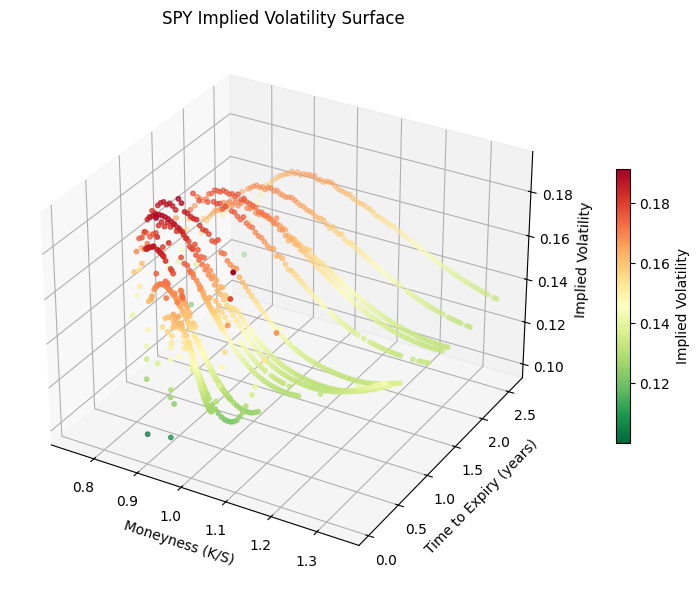

In [67]:
import matplotlib.pyplot as plt

# use calls only for a clean surface
calls_iv = iv_surface[iv_surface['option_type'] == 'call'].copy()

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    calls_iv['moneyness'],
    calls_iv['time_to_expiry'],
    calls_iv['implied_vol'],
    c=calls_iv['implied_vol'],
    cmap='RdYlGn_r',
    s=10
)

fig.colorbar(scatter, ax=ax, shrink=0.5, label='Implied Volatility')

ax.set_xlabel('Moneyness (K/S)')
ax.set_ylabel('Time to Expiry (years)')
ax.set_zlabel('Implied Volatility')
ax.set_title('SPY Implied Volatility Surface')

plt.tight_layout()
# plt.savefig('../results/03_iv_surface.png', dpi=150)
plt.show()

*   **Skew is Clearly Visible**
    - Low moneyness (0.7–0.8) exhibits high implied volatility (IV) indicated in red/orange, representing the deep out-of-the-money (OTM) puts that carry a crash risk premium. 
    - As moneyness approaches 1.0 (at-the-money, or ATM), the IV drops into the green range (0.2–0.25). This pattern forms the equity volatility smirk.

*   **Term Structure is Visible**
    - Short-dated options ($T \approx 0.2$) show a higher IV than long-dated options ($T \approx 1.2$) at the same level of moneyness. 
    - This reflects an inverted term structure, which is typical in stressed markets where near-term uncertainty is elevated. SPY is clearly experiencing a stressed period right now.

*   **The Smile at ATM for Longer Dates**
    - For longer-dated expiries around a moneyness of 1.0–1.1, the IV flattens and rises slightly again. This demonstrates the full volatility smile emerging for longer maturities.

## Interpolating to a surface

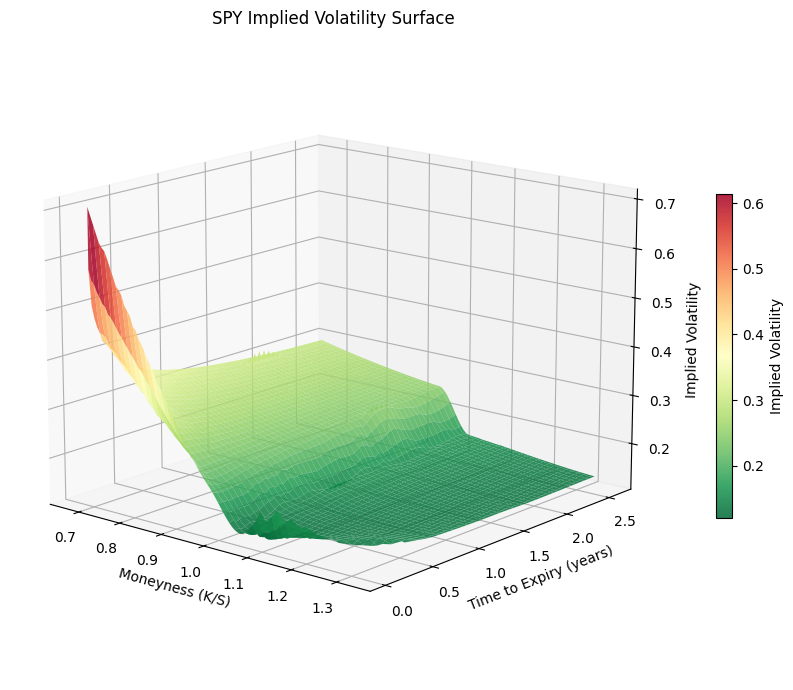

In [69]:
from scipy.interpolate import griddata
import numpy as np

# use OTM only — same convention as smile plot
otm_puts  = iv_surface[(iv_surface['option_type'] == 'put')  & (iv_surface['moneyness'] < 0.97)]
otm_calls = iv_surface[(iv_surface['option_type'] == 'call') & (iv_surface['moneyness'] > 1.03)]
surface_data = pd.concat([otm_puts, otm_calls])

# build regular grid
moneyness_grid = np.linspace(
    surface_data['moneyness'].quantile(0.02),
    surface_data['moneyness'].quantile(0.98),
    100
)
expiry_grid = np.linspace(
    surface_data['time_to_expiry'].min(),
    surface_data['time_to_expiry'].max(),
    100
)
M, T = np.meshgrid(moneyness_grid, expiry_grid)

# interpolate scattered points onto grid
IV_grid = griddata(
    points=surface_data[['moneyness', 'time_to_expiry']].values,
    values=surface_data['implied_vol'].values,
    xi=(M, T),
    method='cubic'
)
IV_grid = np.ma.masked_invalid(IV_grid)  # mask NaN where no data

# plot
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    M, T, IV_grid,
    cmap='RdYlGn_r',
    alpha=0.85,
    edgecolor='none'
)

fig.colorbar(surf, ax=ax, shrink=0.5, label='Implied Volatility')
ax.set_xlabel('Moneyness (K/S)')
ax.set_ylabel('Time to Expiry (years)')
ax.set_zlabel('Implied Volatility')
ax.set_title('SPY Implied Volatility Surface')
ax.view_init(elev=15, azim=-50)  # adjust viewing angle

plt.tight_layout()
plt.savefig('../results/03_iv_surface.png', dpi=150)
plt.show()